In [99]:
from dotenv import load_dotenv
load_dotenv()

True

In [100]:
import os
os.environ["DIRECTORY_PATH"] = os.getenv("DIRECTORY_PATH")

In [101]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model = "gemini-3.6-flash")
output = model.invoke("hi")
output.content

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


[{'type': 'text',
  'text': 'Hello! How can I help you today?',
  'extras': {'signature': 'ErUFCrIFAWkUfRP87/Ppz6cHA6j9OSigiWO64uQcJXTFoRobulBN0p8Zi4ptcaIANhHwV8AeaXFtL/LJeOrfMjQGDuauKELiBdoVh7aJlybnKblK8mll8iZDlQD3FdfKpPwAU1mSL30i4RlrJn6Dgxuaqornw4yCyWEkfRJ9q+cwSLsxVYrnhBfXKzKBfUunEHUzWnyCJ1b02ZqE9dFFZ9sJwkJFLgq0Bd06jWTunr56o+C81XQo4v2zHYYZ+2BV/QNcX7gLH2FFnldX12GsUf9geVuhcb6BO89CmwPLRZWdNx9cqZg39Kd7vtebd8q2tFcp3Cxr6qdUfECxBHAzbhy93b5/u9D0Ot9vi1tXoNpMWfJ2+O5TVIDu0U5BMgGyIay+n7azKRSdiqNitM17XVB9NQfiaxKzK03xHhR5d9PIOQZkN2tnMwMRuW+g2oz+oGyTxmbsKCWW2NU37B/UHN+rBTJ2nyBQhnv7G2KyEw0TVOEduLWhLueeept9mViVpgi+Tm/XszprZ0hPW3cgDm2+Wovs14yrnwheWY/lrqgtalMKhozseA+vUkK7EkalhpRLsMjmx//1uJc11yLVIHXzV+lLcpJOmcIq8Pa0GFUacvwVKKGkHVNg2sPU9N07Iy4wAdfy1p3j2nLSJ8Wi0gZrCOH4F7WjGYBlK4Fpzs1Ybt0lHYhjHdjocmH8U8kolHbL/UfAfE0mEcixfQ1xmF5h3jY6gH4bFWF6oxG8TaTdd/1Yzm4/ew+vi6+wDcFSHFqQcFBK9zcJbjxIX155L1/CkCcMiIaIZhhcBDP7D3ZtOjmhP6rqXJAx3uv6lD8lwwzZiNPIDel16fk8q2wOBDn62zVDtAncJyjLoduFxh038358Gk+fClVbxYnxnshQC0RY8lAFgczVl

In [102]:

from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model = "gemini-embedding-001")
len(embeddings.embed_query("Hi"))

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


3072

In [103]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [104]:
loader = DirectoryLoader(os.environ["DIRECTORY_PATH"] + "\\Source Files", glob= "./*.txt", loader_cls= TextLoader)

In [105]:
docs = loader.load()

In [106]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 200,
    chunk_overlap = 50
)

In [107]:
new_docs = text_splitter.split_documents(docs)

In [108]:
doc_chunks = [doc.page_content for doc in new_docs]

In [109]:
len(doc_chunks)

55

In [110]:
db = Chroma.from_documents(new_docs, embeddings)

In [111]:
retriever = db.as_retriever(search_kwargs = {"k" : 2})

In [112]:
retriever.invoke("Industrial Growth of US?")

[Document(metadata={'source': 'D:\\03_Study\\GenAI\\3.3 Traditional RAG 02\\Source Files\\usa.txt'}, page_content='The U.S. maintains its GDP growth through strong innovation, entrepreneurship, and investment in R&D. With companies like Apple, Google, Amazon, Microsoft, and Tesla leading global markets, the U.S.'),
 Document(metadata={'source': 'D:\\03_Study\\GenAI\\3.3 Traditional RAG 02\\Source Files\\usa.txt'}, page_content='The U.S. maintains its GDP growth through strong innovation, entrepreneurship, and investment in R&D. With companies like Apple, Google, Amazon, Microsoft, and Tesla leading global markets, the U.S.')]

In [113]:
from pydantic import BaseModel, Field
class TopicSelectionParser(BaseModel):
    Topic:str = Field("Selected Topic")
    Reasoning:str = Field("Reason of selecting Topic")


In [114]:
from langchain_core.output_parsers import PydanticOutputParser
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
import operator


In [115]:
parser = PydanticOutputParser(pydantic_object = TopicSelectionParser)

In [116]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"default": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"default": "Reason of selecting Topic", "title": "Reasoning", "type": "string"}}}\n```'

In [117]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],operator.add]

In [118]:
def function_1(state: AgentState):
    question = state['messages'][-1]


    #chain = prompt | model | parser 

In [119]:
def function_2(state: AgentState):
    pass

In [120]:
def function_3(state: AgentState):
    pass

In [121]:
def router(state: AgentState):
    pass

In [122]:
from langgraph.graph import StateGraph, START, END

In [123]:
workflow = StateGraph(AgentState)

In [124]:
workflow.add_node("Supervisor",function_1)
workflow.add_node("RAG",function_2)
workflow.add_node("LLM", function_3)


In [125]:
workflow.set_entry_point("Supervisor")
workflow.add_conditional_edges(
            "Supervisor", router , 
            {"RAG Call" : "RAG", "LLM Call" : "LLM"} 
            )
workflow.add_edge("RAG", END)
workflow.add_edge("LLM", END)

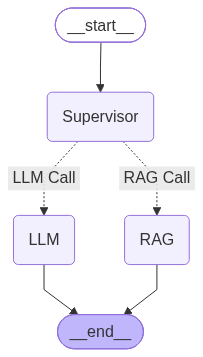

In [126]:
workflow.compile()